# H6: Clinical Individual Differences (Exploratory)

Test whether the joint optimal-control parameters (ω capture cost, κ effort cost) carry any signal about the psychiatric battery in BOTH samples.

**Pipeline:**
1. Frequentist Pearson sweep across 13 clinical scales × {ω, κ, angle}, FDR-corrected within sample × param.
2. Strict replication: FDR-significant in exploratory + uncorrected p<0.05 with same sign in confirmatory.
3. Bayesian follow-up on any survivors (full posterior + 95% HDI).
4. EFA on exploratory subscales → 3-factor solution → projected to confirmatory → factor scores vs ω, κ, angle.
5. Dissociation plot in (r_ω, r_κ) plane.

**Pre-specified expectation:** if a story exists, ω should preferentially track threat/anxiety scales (OASIS, STICSA, DASS-Anx, STAI-T) and κ should track motivation/fatigue scales (AMI subscales, MFIS).

Note: this notebook is *exploratory* — not part of the H1–H5 prereg. Any finding must replicate in confirmatory to count.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys
if '/workspace/notebooks/analysis' not in sys.path:
    sys.path.insert(0, '/workspace/notebooks/analysis')
import numpy as np, pandas as pd
import bambi as bmb, arviz as az
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import FactorAnalysis
from config import *
from load_data import load_both

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9,
                     'axes.spines.right': False, 'axes.spines.top': False})

OUT_DIR = REPO_ROOT / 'results' / 'figs' / 'clinical'
OUT_DIR.mkdir(parents=True, exist_ok=True)
STATS_DIR = REPO_ROOT / 'results' / 'stats' / 'clinical'
STATS_DIR.mkdir(parents=True, exist_ok=True)

exp_data, conf_data = load_both()
all_data = {'exploratory': exp_data, 'confirmatory': conf_data}
all_data = {k: v for k, v in all_data.items() if v is not None}

for name, d in all_data.items():
    print(f'{d["config"].label}: master={len(d["master"])} subjects')

Exploratory (N=290): stage5_filtered_data_20260403_133425 | params: 290 subjects
Confirmatory (N=281): stage5_filtered_data_20260403_142413 | params: 281 subjects
GPU: No


Exploratory (N=290): master=290 subjects
Confirmatory (N=281): master=281 subjects


## Inspect available clinical scales

In [2]:
SCALES = [
    'DASS21_Stress', 'DASS21_Anxiety', 'DASS21_Depression',
    'AMI_Behavioural', 'AMI_Social', 'AMI_Emotional',
    'MFIS_Physical', 'MFIS_Cognitive', 'MFIS_Psychosocial',
    'OASIS_Total', 'PHQ9_Total', 'STICSA_Total', 'STAI_Trait',
]

summary_rows = []
for sc in SCALES:
    row = {'scale': sc}
    for name in all_data:
        m = all_data[name]['master']
        if sc in m.columns:
            v = m[sc].dropna()
            row[f'{name[:4]}_n'] = len(v)
            row[f'{name[:4]}_mean'] = round(v.mean(), 2)
            row[f'{name[:4]}_sd'] = round(v.std(), 2)
        else:
            row[f'{name[:4]}_n'] = 0
    summary_rows.append(row)
print(pd.DataFrame(summary_rows).to_string(index=False))

            scale  expl_n  expl_mean  expl_sd  conf_n  conf_mean  conf_sd
    DASS21_Stress     290      11.28    10.00     281      11.47    10.16
   DASS21_Anxiety     290       7.92     8.86     281       8.65     9.42
DASS21_Depression     290      11.51    12.13     281      10.42    11.29
  AMI_Behavioural     290       9.24     5.68     281       8.14     5.54
       AMI_Social     290      12.00     5.40     281      10.63     5.09
    AMI_Emotional     290       6.81     3.77     281       5.74     3.70
    MFIS_Physical     289      11.88     8.66     281      12.12     9.24
   MFIS_Cognitive     289      13.27     9.29     281      13.00     9.87
MFIS_Psychosocial     289       3.13     2.46     281       3.13     2.52
      OASIS_Total     290       6.25     4.70     281       5.96     5.00
       PHQ9_Total     290       7.62     6.40     281       7.42     6.53
     STICSA_Total     290      36.23    13.50     281      35.95    13.79
       STAI_Trait     289      51.30  

In [3]:
# Z-score each scale within sample for comparable effect sizes
for name, d in all_data.items():
    m = d['master']
    for sc in SCALES:
        if sc in m.columns:
            v = m[sc]
            mu, sd = v.mean(), v.std()
            m[f'{sc}_z'] = (v - mu) / sd if sd > 0 else np.nan
    d['master'] = m
print('Scales z-scored within sample.')

Scales z-scored within sample.


## Step 1 — Frequentist Pearson sweep with FDR

For each (sample, scale, param) compute Pearson r and FDR-corrected p across the 13 scales (per sample × param).

In [4]:
freq_rows = []
for name, d in all_data.items():
    m = d['master']
    for sc in SCALES:
        if sc not in m.columns:
            continue
        for param in ['omega_z', 'kappa_z', 'angle_z']:
            df = m[[param, sc]].dropna()
            if len(df) < 30:
                continue
            r, p = pearsonr(df[param], df[sc])
            freq_rows.append({
                'sample': name, 'scale': sc, 'param': param,
                'r': r, 'p': p, 'n': len(df),
            })

freq = pd.DataFrame(freq_rows)
freq['p_fdr'] = np.nan
for (s, p), grp in freq.groupby(['sample', 'param']):
    _, p_adj, _, _ = multipletests(grp['p'].values, method='fdr_bh')
    freq.loc[grp.index, 'p_fdr'] = p_adj
freq['sig_uncorr'] = freq['p'] < 0.05
freq['sig_fdr'] = freq['p_fdr'] < 0.05
freq.to_csv(STATS_DIR / 'clinical_pearson_sweep.csv', index=False)

for param in ['omega_z', 'kappa_z', 'angle_z']:
    print(f'\n=== {param} ===')
    sub = freq[freq['param'] == param]
    piv = sub.pivot(index='scale', columns='sample', values=['r', 'p', 'p_fdr'])
    piv = piv.reindex(SCALES)
    print(piv.round(4).to_string())


=== omega_z ===
                             r                        p                    p_fdr            
sample            confirmatory exploratory confirmatory exploratory confirmatory exploratory
scale                                                                                       
DASS21_Stress          -0.0698     -0.0675       0.2435      0.2522       0.6382      0.6413
DASS21_Anxiety         -0.0294     -0.0597       0.6235      0.3111       0.7328      0.6413
DASS21_Depression      -0.0269     -0.0279       0.6532      0.6366       0.7328      0.7524
AMI_Behavioural         0.0683     -0.0056       0.2536      0.9239       0.6382      0.9239
AMI_Social              0.1552      0.0828       0.0091      0.1596       0.1189      0.6413
AMI_Emotional           0.0901      0.1001       0.1321      0.0889       0.6382      0.6413
MFIS_Physical          -0.0259     -0.0553       0.6658      0.3491       0.7328      0.6413
MFIS_Cognitive         -0.0205     -0.0503       0.73

## Step 2 — Replication table

- **STRICT** = FDR-sig in exp AND uncorrected p<0.05 in conf AND same sign  (preregistration logic: discovery sample tested with FDR, confirmation sample uses directional one-tailed standard)
- **LOOSE**  = uncorrected p<0.05 in BOTH samples AND same sign (sanity)

In [5]:
rep_rows = []
for param in ['omega_z', 'kappa_z', 'angle_z']:
    for sc in SCALES:
        e = freq[(freq['sample']=='exploratory') & (freq['scale']==sc) & (freq['param']==param)]
        c = freq[(freq['sample']=='confirmatory') & (freq['scale']==sc) & (freq['param']==param)]
        if len(e)==0 or len(c)==0:
            continue
        e = e.iloc[0]; c = c.iloc[0]
        same_sign = np.sign(e['r']) == np.sign(c['r'])
        rep_strict = bool(e['sig_fdr']) and (c['p'] < 0.05) and same_sign
        rep_loose  = bool(e['sig_uncorr']) and (c['p'] < 0.05) and same_sign
        rep_rows.append({
            'param': param, 'scale': sc,
            'r_exp': e['r'], 'p_fdr_exp': e['p_fdr'],
            'r_conf': c['r'], 'p_conf': c['p'],
            'same_sign': same_sign,
            'replicates_strict': rep_strict,
            'replicates_loose':  rep_loose,
        })
rep_df = pd.DataFrame(rep_rows)
rep_df.to_csv(STATS_DIR / 'clinical_replication.csv', index=False)

print('=== STRICT replication (FDR in exp, p<.05 + same sign in conf) ===')
strict = rep_df[rep_df['replicates_strict']]
print('  NONE' if len(strict)==0 else strict.round(4).to_string(index=False))

print('\n=== LOOSE replication (uncorrected p<.05 + same sign in BOTH) ===')
loose = rep_df[rep_df['replicates_loose']]
print('  NONE' if len(loose)==0 else loose.round(4).to_string(index=False))

=== STRICT replication (FDR in exp, p<.05 + same sign in conf) ===
  NONE

=== LOOSE replication (uncorrected p<.05 + same sign in BOTH) ===
  NONE


## Step 3 — Bayesian follow-up on survivors

Full HDI inference on whichever (scale × param) pairs replicated. If nothing replicates, runs the top 5 exploratory hits for completeness.

In [6]:
if len(rep_df[rep_df['replicates_loose']]) > 0:
    survivors = rep_df[rep_df['replicates_loose']][['scale']].drop_duplicates()
    print(f'Bayesian follow-up on {len(survivors)} replicating scales')
else:
    survivors = rep_df.nsmallest(5, 'p_fdr_exp')[['scale']].drop_duplicates()
    print(f'No replication — running Bayesian on top 5 exploratory hits for completeness')

bayes_rows = []
for sc in survivors['scale'].unique():
    for name, d in all_data.items():
        m = d['master']
        zcol = f'{sc}_z'
        if zcol not in m.columns:
            continue
        df = m[['omega_z','kappa_z', zcol]].dropna()
        if len(df) < 30:
            continue
        try:
            mod = bmb.Model(f'{zcol} ~ omega_z + kappa_z', data=df)
            res = mod.fit(**BKW)
            s = az.summary(res, hdi_prob=0.95)
            for term in ['omega_z','kappa_z']:
                lo = s.loc[term, 'hdi_2.5%']; hi = s.loc[term, 'hdi_97.5%']
                bayes_rows.append({
                    'sample': name, 'scale': sc, 'term': term,
                    'b': s.loc[term, 'mean'], 'lo': lo, 'hi': hi,
                    'sig': (lo > 0) or (hi < 0),
                })
        except Exception as e:
            print(f'  Failed: {sc} {name}: {e}')

bayes = pd.DataFrame(bayes_rows)
bayes.to_csv(STATS_DIR / 'clinical_bayes_followup.csv', index=False)
if len(bayes):
    print(bayes.round(3).to_string(index=False))

No replication — running Bayesian on top 5 exploratory hits for completeness


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, omega_z, kappa_z]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, omega_z, kappa_z]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


      sample          scale    term      b     lo    hi   sig
 exploratory  DASS21_Stress omega_z -0.054 -0.180 0.072 False
 exploratory  DASS21_Stress kappa_z -0.034 -0.164 0.091 False
confirmatory  DASS21_Stress omega_z -0.100 -0.229 0.023 False
confirmatory  DASS21_Stress kappa_z  0.101 -0.022 0.223 False
 exploratory DASS21_Anxiety omega_z -0.049 -0.172 0.073 False
 exploratory DASS21_Anxiety kappa_z -0.028 -0.148 0.100 False
confirmatory DASS21_Anxiety omega_z -0.035 -0.155 0.093 False
confirmatory DASS21_Anxiety kappa_z  0.021 -0.103 0.151 False
 exploratory     AMI_Social omega_z  0.115 -0.006 0.240 False
 exploratory     AMI_Social kappa_z -0.088 -0.208 0.040 False
confirmatory     AMI_Social omega_z  0.162  0.036 0.282  True
confirmatory     AMI_Social kappa_z -0.024 -0.148 0.096 False
 exploratory  AMI_Emotional omega_z  0.125  0.002 0.253  True
 exploratory  AMI_Emotional kappa_z -0.067 -0.192 0.055 False
confirmatory  AMI_Emotional omega_z  0.083 -0.038 0.206 False
confirma

## Step 4 — EFA: do params predict latent psych factors?

Fit 3-factor varimax-rotated EFA on exploratory subscales; project the loadings onto confirmatory subjects (same μ/σ from exploratory). Then correlate factor scores with ω, κ, angle.

In [7]:
exp_m = all_data['exploratory']['master']
X_exp = exp_m[SCALES].dropna()
print(f'EFA fit on N={len(X_exp)} exploratory subjects')

mu_exp = X_exp.mean()
sd_exp = X_exp.std().replace(0, 1)
X_exp_z = (X_exp - mu_exp) / sd_exp

fa = FactorAnalysis(n_components=3, rotation='varimax', random_state=42)
fa.fit(X_exp_z.values)

loadings = pd.DataFrame(fa.components_.T, index=SCALES, columns=['F1','F2','F3'])
print('\n=== Factor loadings (varimax) ===')
print(loadings.round(2).to_string())
loadings.to_csv(STATS_DIR / 'clinical_efa_loadings.csv')

# Project to both samples using exploratory's μ/σ
for name, d in all_data.items():
    m = d['master']
    X = m[SCALES]
    X_z = (X - mu_exp) / sd_exp
    valid = X_z.dropna().index
    if len(valid) == 0:
        continue
    scores = pd.DataFrame(
        fa.transform(X_z.loc[valid].values),
        index=valid, columns=['F1','F2','F3'])
    for f in ['F1','F2','F3']:
        m[f] = np.nan
        m.loc[valid, f] = scores[f]
    d['master'] = m

fa_rows = []
for name, d in all_data.items():
    m = d['master']
    for f in ['F1','F2','F3']:
        for p in ['omega_z','kappa_z','angle_z']:
            df = m[[f, p]].dropna()
            if len(df) < 30:
                continue
            r, pv = pearsonr(df[f], df[p])
            fa_rows.append({'sample': name, 'factor': f, 'param': p,
                            'r': r, 'p': pv, 'n': len(df)})
fa_df = pd.DataFrame(fa_rows)
fa_df['p_fdr'] = np.nan
for (s, p), grp in fa_df.groupby(['sample','param']):
    _, p_adj, _, _ = multipletests(grp['p'].values, method='fdr_bh')
    fa_df.loc[grp.index, 'p_fdr'] = p_adj
fa_df.to_csv(STATS_DIR / 'clinical_factor_correlations.csv', index=False)

print('\n=== Factor scores ↔ params ===')
print(fa_df.round(4).to_string(index=False))

EFA fit on N=288 exploratory subjects

=== Factor loadings (varimax) ===
                     F1    F2    F3
DASS21_Stress      0.78 -0.38 -0.22
DASS21_Anxiety     0.84 -0.24 -0.00
DASS21_Depression  0.66 -0.35 -0.51
AMI_Behavioural    0.22 -0.40 -0.55
AMI_Social         0.12 -0.18 -0.62
AMI_Emotional     -0.35  0.24 -0.16
MFIS_Physical      0.49 -0.77 -0.10
MFIS_Cognitive     0.46 -0.75 -0.24
MFIS_Psychosocial  0.39 -0.67 -0.34
OASIS_Total        0.71 -0.42 -0.20
PHQ9_Total         0.72 -0.40 -0.39
STICSA_Total       0.86 -0.34 -0.10
STAI_Trait        -0.53  0.38  0.35

=== Factor scores ↔ params ===
      sample factor   param       r      p   n  p_fdr
 exploratory     F1 omega_z -0.0581 0.3257 288 0.3763
 exploratory     F1 kappa_z -0.0273 0.6446 288 0.6446
 exploratory     F1 angle_z -0.0462 0.4346 288 0.6519
 exploratory     F2 omega_z  0.0523 0.3763 288 0.3763
 exploratory     F2 kappa_z  0.0654 0.2687 288 0.4873
 exploratory     F2 angle_z  0.0107 0.8566 288 0.8566
 exploratory 

## Step 5 — Dissociation plot in (r_ω, r_κ) plane

If ω and κ have separable clinical signatures, scales should cluster in distinct regions of the plane. Both samples shown side-by-side as a visual replication check.

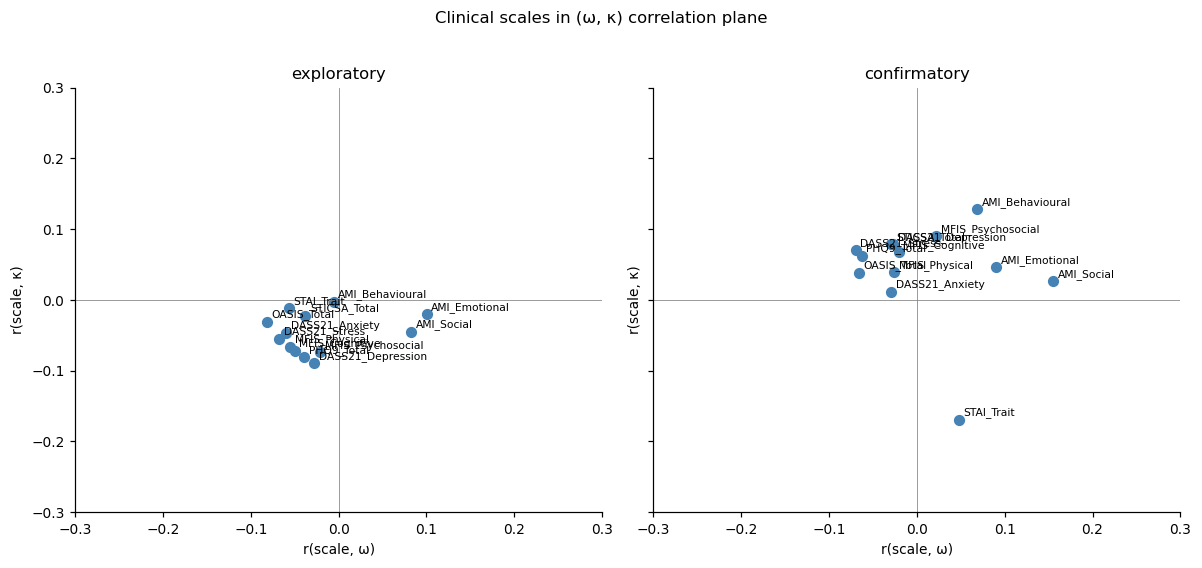

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, name in zip(axes, ['exploratory','confirmatory']):
    sub = freq[freq['sample']==name]
    omega = sub[sub['param']=='omega_z'].set_index('scale')['r']
    kappa = sub[sub['param']=='kappa_z'].set_index('scale')['r']
    common = omega.index.intersection(kappa.index)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    for sc in common:
        ax.scatter(omega[sc], kappa[sc], s=40, color='steelblue')
        ax.annotate(sc, (omega[sc], kappa[sc]),
                    fontsize=7, xytext=(3,3), textcoords='offset points')
    ax.set_xlabel('r(scale, ω)')
    ax.set_ylabel('r(scale, κ)')
    ax.set_title(f'{name}')
    lim = max(0.3, abs(np.r_[omega.values, kappa.values]).max() * 1.1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
plt.suptitle('Clinical scales in (ω, κ) correlation plane', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'clinical_dissociation.png', dpi=150, bbox_inches='tight')
plt.show()

## Verdict

In [9]:
print('=' * 70)
print('H6 CLINICAL EXPLORATION — VERDICT')
print('=' * 70)
print(f'\nSamples: exp N={len(all_data["exploratory"]["master"])}, '
      f'conf N={len(all_data["confirmatory"]["master"])}')
print(f'Scales tested: {len(SCALES)} | Params: ω, κ, angle')

strict = rep_df[rep_df['replicates_strict']]
loose  = rep_df[rep_df['replicates_loose']]
print(f'\nBivariate scale × param associations:')
print(f'  STRICT (FDR exp + p<.05 conf, same sign): {len(strict)}')
print(f'  LOOSE  (p<.05 in both, same sign):        {len(loose)}')

if len(strict):
    print('\nSTRICT replicators:')
    for _, r in strict.iterrows():
        print(f'  {r["scale"]:<22} × {r["param"]:<8}: '
              f'exp r={r["r_exp"]:+.3f}, conf r={r["r_conf"]:+.3f}')
elif len(loose):
    print('\nLOOSE replicators (note: not preregistered, treat as suggestive):')
    for _, r in loose.iterrows():
        print(f'  {r["scale"]:<22} × {r["param"]:<8}: '
              f'exp r={r["r_exp"]:+.3f}, conf r={r["r_conf"]:+.3f}')

print('\nFactor analysis (3 factors, exp-fit projected to conf):')
for _, r in fa_df.iterrows():
    flag = '*' if r['p'] < 0.05 else ' '
    print(f'  {r["sample"][:4]} {r["factor"]} ↔ {r["param"]:<8}: '
          f'r={r["r"]:+.3f} p={r["p"]:.3f}{flag}')

print('\nFactor associations replicating across samples (same factor, same param,')
print('p<.05 in both, same sign):')
any_rep = False
for f in ['F1','F2','F3']:
    for p in ['omega_z','kappa_z','angle_z']:
        e = fa_df[(fa_df['sample']=='exploratory') & (fa_df['factor']==f) & (fa_df['param']==p)]
        c = fa_df[(fa_df['sample']=='confirmatory') & (fa_df['factor']==f) & (fa_df['param']==p)]
        if len(e)==0 or len(c)==0:
            continue
        e = e.iloc[0]; c = c.iloc[0]
        if e['p']<0.05 and c['p']<0.05 and np.sign(e['r'])==np.sign(c['r']):
            print(f'  {f} × {p}: exp r={e["r"]:+.3f}, conf r={c["r"]:+.3f}')
            any_rep = True
if not any_rep:
    print('  NONE')

print('\nOutputs:')
print(f'  {STATS_DIR}/clinical_pearson_sweep.csv')
print(f'  {STATS_DIR}/clinical_replication.csv')
print(f'  {STATS_DIR}/clinical_bayes_followup.csv')
print(f'  {STATS_DIR}/clinical_efa_loadings.csv')
print(f'  {STATS_DIR}/clinical_factor_correlations.csv')
print(f'  {OUT_DIR}/clinical_dissociation.png')

H6 CLINICAL EXPLORATION — VERDICT

Samples: exp N=290, conf N=281
Scales tested: 13 | Params: ω, κ, angle

Bivariate scale × param associations:
  STRICT (FDR exp + p<.05 conf, same sign): 0
  LOOSE  (p<.05 in both, same sign):        0

Factor analysis (3 factors, exp-fit projected to conf):
  expl F1 ↔ omega_z : r=-0.058 p=0.326 
  expl F1 ↔ kappa_z : r=-0.027 p=0.645 
  expl F1 ↔ angle_z : r=-0.046 p=0.435 
  expl F2 ↔ omega_z : r=+0.052 p=0.376 
  expl F2 ↔ kappa_z : r=+0.065 p=0.269 
  expl F2 ↔ angle_z : r=+0.011 p=0.857 
  expl F3 ↔ omega_z : r=-0.070 p=0.235 
  expl F3 ↔ kappa_z : r=+0.058 p=0.325 
  expl F3 ↔ angle_z : r=+0.053 p=0.366 
  conf F1 ↔ omega_z : r=-0.077 p=0.199 
  conf F1 ↔ kappa_z : r=+0.042 p=0.481 
  conf F1 ↔ angle_z : r=+0.046 p=0.442 
  conf F2 ↔ omega_z : r=+0.006 p=0.917 
  conf F2 ↔ kappa_z : r=-0.053 p=0.380 
  conf F2 ↔ angle_z : r=-0.093 p=0.121 
  conf F3 ↔ omega_z : r=-0.079 p=0.188 
  conf F3 ↔ kappa_z : r=-0.111 p=0.065 
  conf F3 ↔ angle_z : r=-0